In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import noisereduce as nr

# 1. Cargar el audio (Asegúrate de que 'Prueba.wav' esté en la misma carpeta)
samplerate, data = wavfile.read('Prueba.wav')

# Si el audio es estéreo (2 canales), nos quedamos con uno solo para procesarlo
if len(data.shape) > 1:
    data = data[:, 0]

# Crear un vector de tiempo (nos servirá para los gráficos)
n = len(data)
dt = 1.0 / samplerate
t = np.arange(0, n) * dt

print(f"Audio cargado exitosamente. Frecuencia de muestreo: {samplerate} Hz")
print(f"Duración del audio: {n/samplerate:.2f} segundos")

Audio cargado exitosamente. Frecuencia de muestreo: 48000 Hz
Duración del audio: 12.48 segundos


In [4]:
# 2. Aplicar Reducción de Ruido Avanzada
# El parámetro stationary=False hace que el algoritmo se adapte a 
# ruidos cambiantes y respete las frecuencias de la voz humana.
print("Procesando la reducción de ruido espectral... (Esto puede tardar unos segundos)")

audio_limpio = nr.reduce_noise(y=data, sr=samplerate, stationary=False)

# 3. Exportar el resultado a un nuevo archivo reproducible
nombre_archivo_salida = 'Prueba_Voces_Limpias.wav'
wavfile.write(nombre_archivo_salida, samplerate, audio_limpio)

print(f"¡Procesamiento completado! Se ha guardado tu nuevo archivo como '{nombre_archivo_salida}'")

Procesando la reducción de ruido espectral... (Esto puede tardar unos segundos)
¡Procesamiento completado! Se ha guardado tu nuevo archivo como 'Prueba_Voces_Limpias.wav'


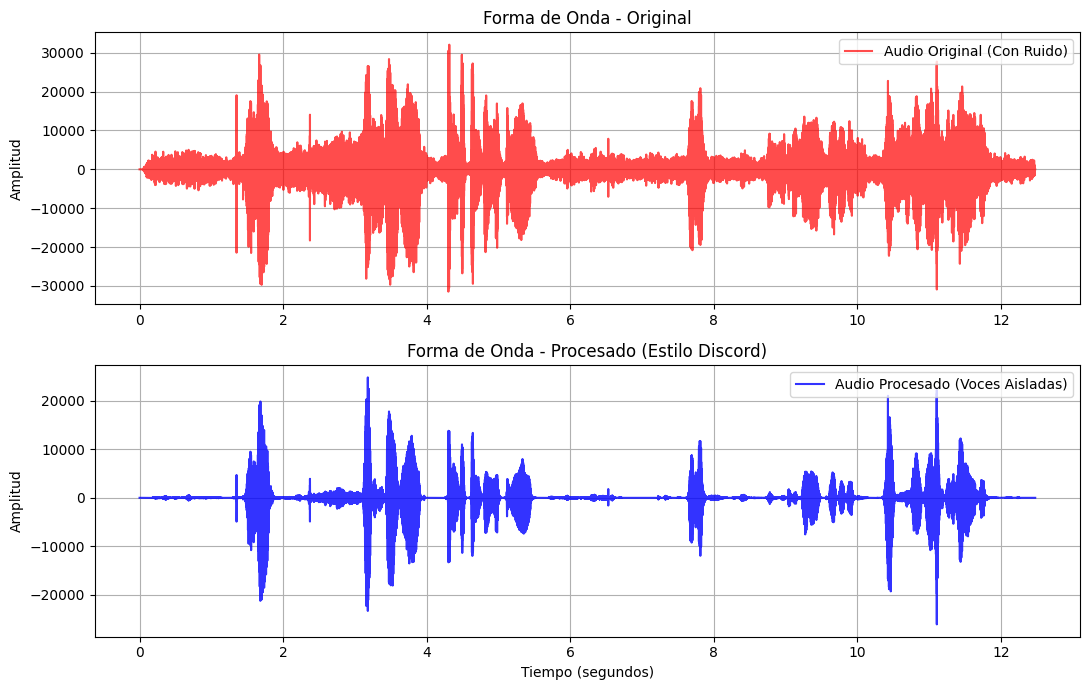

In [5]:
# 4. Graficar la comparativa de las formas de onda
fig, axs = plt.subplots(2, 1, figsize=(11, 7))

# Gráfico del audio original con ruido
axs[0].plot(t, data, color='red', alpha=0.7, label='Audio Original (Con Ruido)')
axs[0].set_title('Forma de Onda - Original')
axs[0].set_ylabel('Amplitud')
axs[0].legend(loc="upper right")
axs[0].grid(True)

# Gráfico del audio procesado (limpio)
axs[1].plot(t, audio_limpio, color='blue', alpha=0.8, label='Audio Procesado (Voces Aisladas)')
axs[1].set_title('Forma de Onda - Procesado (Estilo Discord)')
axs[1].set_xlabel('Tiempo (segundos)')
axs[1].set_ylabel('Amplitud')
axs[1].legend(loc="upper right")
axs[1].grid(True)

plt.tight_layout()
plt.show()